# English to French Translation with Seq2Seq (PyTorch)

Neural machine translation model built from scratch in PyTorch.

`I am happy` -> `je suis heureux`

### Architecture
1. Encoder: bidirectional LSTM that reads the English sentence
2. Attention: decides which English words matter at each decoding step
3. Decoder: LSTM that writes the French sentence one word at a time

> Runtime tip: turn on a GPU if you can (Kaggle, Colab, or local CUDA). CPU works too, just slower.


## 1. Setup and configuration

In [18]:
import os
import re
import math
import time
import random
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


### Workshop knobs

`WORKSHOP_MODE = True` trains on a smaller subset so things finish in a reasonable time during a live session. Flip it to `False` when you want the full run, closer to how the original notebook does it.


In [19]:
# True  = faster demo (recommended during the workshop)
# False = full dataset, closer to the original TensorFlow notebook
WORKSHOP_MODE = False

CONFIG = {
    "subset_size": 40_000 if WORKSHOP_MODE else None,  # None = use all pairs
    "max_vocab_size": 8_000 if WORKSHOP_MODE else 10_000,
    "max_seq_len": 20 if WORKSHOP_MODE else 40,
    "embed_dim": 256,
    "hidden_dim": 256,          # encoder hidden size (per direction)
    "decoder_hidden": 512,      # 256 * 2 after we merge bidirectional states
    "batch_size": 64,
    "epochs": 8 if WORKSHOP_MODE else 15,
    "learning_rate": 1e-3,
    "dropout": 0.2,
    "patience": 3,              # early stopping
    "grad_clip": 1.0,
    "num_workers": 0,           # keep 0 on Windows / notebooks
}

print("Training config")
for key, value in CONFIG.items():
    print(f"  {key:16s}: {value}")


Training config
  subset_size     : None
  max_vocab_size  : 10000
  max_seq_len     : 40
  embed_dim       : 256
  hidden_dim      : 256
  decoder_hidden  : 512
  batch_size      : 64
  epochs          : 15
  learning_rate   : 0.001
  dropout         : 0.2
  patience        : 3
  grad_clip       : 1.0
  num_workers     : 0


## 2. Load the dataset

In [20]:
def _read_csv_pairs(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    # Kaggle file uses English / French column names
    cols = {c.lower().strip(): c for c in df.columns}
    eng_col = cols.get("english") or cols.get("en") or list(df.columns)[0]
    fr_col = cols.get("french") or cols.get("fr") or list(df.columns)[1]
    out = df[[eng_col, fr_col]].copy()
    out.columns = ["English", "French"]
    return out.dropna()


def _read_tsv_pairs(path: str) -> pd.DataFrame:
    rows = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) >= 2:
                rows.append((parts[0], parts[1]))
    return pd.DataFrame(rows, columns=["English", "French"])


def _download_anki_fra_eng(dest_dir: Path) -> Path:
    """Official PyTorch tutorial data: English \\t French pairs."""
    import urllib.request
    import zipfile

    dest_dir.mkdir(parents=True, exist_ok=True)
    zip_path = dest_dir / "anki_data.zip"
    txt_path = dest_dir / "eng-fra.txt"
    if txt_path.exists():
        return txt_path

    url = "https://download.pytorch.org/tutorial/data.zip"
    print(f"Downloading translation pairs from {url} ...")
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        # archive contains data/eng-fra.txt
        for name in zf.namelist():
            if name.endswith("eng-fra.txt"):
                zf.extract(name, dest_dir)
                extracted = dest_dir / name
                extracted.replace(txt_path)
                break
    print(f"Saved to {txt_path}")
    return txt_path


def load_translation_dataframe() -> pd.DataFrame:
    candidates = [
        "/kaggle/input/language-translation-englishfrench/eng_-french.csv",
        "data/eng_-french.csv",
        "eng_-french.csv",
        str(Path.cwd() / "data" / "eng_-french.csv"),
        str(Path.home() / "Downloads" / "eng_-french.csv"),
        str(Path.cwd() / "eng_-french.csv"),
    ]
    for path in candidates:
        if os.path.exists(path):
            print(f"Loaded local CSV: {path}")
            return _read_csv_pairs(path)

    txt_path = _download_anki_fra_eng(Path.cwd() / "data")
    print(f"Loaded Anki / Tatoeba file: {txt_path}")
    return _read_tsv_pairs(txt_path)


df = load_translation_dataframe()
df = df[df["English"].astype(str).str.strip().ne("") & df["French"].astype(str).str.strip().ne("")]
df = df.drop_duplicates(subset=["English", "French"]).reset_index(drop=True)

if CONFIG["subset_size"] is not None and len(df) > CONFIG["subset_size"]:
    df = df.sample(n=CONFIG["subset_size"], random_state=SEED).reset_index(drop=True)
    print(f"Workshop subset: using {len(df):,} sentence pairs")
else:
    print(f"Using the full cleaned set: {len(df):,} sentence pairs")

df.head(8)


Loaded local CSV: data/eng_-french.csv
Using the full cleaned set: 175,621 sentence pairs


,English,French
0,Hi.,Salut!
1,Run!,Cours !
2,Run!,Courez !
3,Who?,Qui ?
4,Wow!,Ça alors !
5,Fire!,Au feu !
6,Help!,À l'aide !
7,Jump.,Saute.


### Quick look at the data

Before cleaning anything, let's check sentence lengths and a few raw examples. Most everyday sentences in this dataset are short, which is why max length 20 is plenty in workshop mode.


Pairs: 175,621

Random examples:
  EN: Take a seat.
  FR: Prends place !

  EN: I wish Tom was here.
  FR: J'aimerais que Tom soit là.

  EN: How did the audition go?
  FR: Comment s'est passée l'audition ?

  EN: I've no friend to talk to about my problems.
  FR: Je n'ai pas d'ami avec lequel je puisse m'entretenir de mes problèmes.

  EN: I really like this skirt. Can I try it on?
  FR: J'aime beaucoup cette jupe, puis-je l'essayer ?

English words, mean 6.2, max 44
French words, mean 6.7, max 55


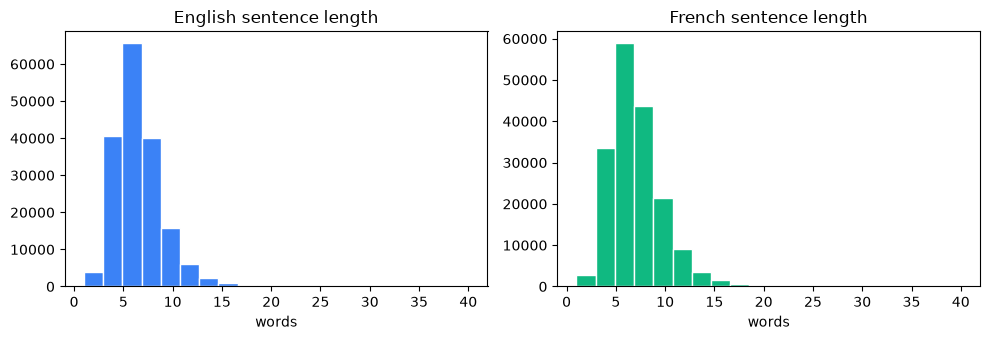

In [21]:
print(f"Pairs: {len(df):,}")
print("\nRandom examples:")
for _, row in df.sample(5, random_state=SEED).iterrows():
    print(f"  EN: {row['English']}")
    print(f"  FR: {row['French']}\n")

eng_lens = df["English"].astype(str).str.split().str.len()
fr_lens = df["French"].astype(str).str.split().str.len()
print(f"English words, mean {eng_lens.mean():.1f}, max {eng_lens.max()}")
print(f"French words, mean {fr_lens.mean():.1f}, max {fr_lens.max()}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(eng_lens.clip(upper=40), bins=20, color="#3b82f6", edgecolor="white")
axes[0].set_title("English sentence length")
axes[0].set_xlabel("words")
axes[1].hist(fr_lens.clip(upper=40), bins=20, color="#10b981", edgecolor="white")
axes[1].set_title("French sentence length")
axes[1].set_xlabel("words")
plt.tight_layout()
plt.show()


## 3. Text cleaning

Neural models need consistent input, so we do a few things:

1. Lowercase everything (`Hi.` and `hi` should be the same token)
2. Expand common contractions (`don't` -> `do not`)
3. Keep letters (and French accents) plus spaces, drop everything else
4. Collapse repeated spaces

We don't add `<start>` / `<end>` at this stage. Those get added later when we turn text into IDs, it's cleaner that way instead of baking them into raw strings.


In [22]:
EN_CONTRACTIONS = {
    "i'm": "i am", "you're": "you are", "he's": "he is", "she's": "she is",
    "it's": "it is", "we're": "we are", "they're": "they are",
    "i've": "i have", "you've": "you have", "we've": "we have", "they've": "they have",
    "i'll": "i will", "you'll": "you will", "he'll": "he will", "she'll": "she will",
    "we'll": "we will", "they'll": "they will",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "can't": "cannot", "couldn't": "could not", "won't": "will not",
    "wouldn't": "would not", "shouldn't": "should not", "haven't": "have not",
    "hasn't": "has not", "hadn't": "had not", "let's": "let us",
}

FR_CONTRACTIONS = {
    "c'est": "ce est", "j'ai": "je ai", "n'est": "ne est",
    "qu'est": "que est", "d'accord": "de accord", "l'est": "le est",
}

# Letters we keep for French (accents + oe ligature)
FR_KEEP = r"a-zàâäçéèêëîïôùûüœÿ\s"


def _expand(text: str, table: dict) -> str:
    for src_tok, dst_tok in table.items():
        text = re.sub(rf"\b{re.escape(src_tok)}\b", dst_tok, text)
    return text


def clean_english(text: str) -> str:
    text = str(text).lower().strip()
    text = _expand(text, EN_CONTRACTIONS)
    text = re.sub(r"[^a-z\s]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def clean_french(text: str) -> str:
    text = str(text).lower().strip()
    text = _expand(text, FR_CONTRACTIONS)
    text = re.sub(rf"[^{FR_KEEP}]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


df["English"] = df["English"].map(clean_english)
df["French"] = df["French"].map(clean_french)
df = df[(df["English"].str.len() > 0) & (df["French"].str.len() > 0)].reset_index(drop=True)

print("After cleaning:")
for _, row in df.head(5).iterrows():
    print(f"  {row['English']:30s}  →  {row['French']}")


After cleaning:
  hi                              →  salut
  run                             →  cours
  run                             →  courez
  who                             →  qui
  wow                             →  ça alors


## 4. Train / validation / test split

We hold out 10% for test (the final numbers) and 10% of what's left for validation (early stopping). The vocabulary only gets built from the training set, so the model never sees test words while it's building its dictionary.


In [23]:
train_df, test_df = train_test_split(df, test_size=0.10, random_state=SEED)
train_df, val_df = train_test_split(train_df, test_size=0.10, random_state=SEED)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df):,}")
print(f"Valid: {len(val_df):,}")
print(f"Test : {len(test_df):,}")


Train: 142,252
Valid: 15,806
Test : 17,563


## 5. Vocabulary and numericalization

A neural net can't read strings, so we map every word to an integer ID.

| Token | ID | Role |
|---|---|---|
| `<pad>` | 0 | Fills shorter sentences so a batch stays a rectangular tensor |
| `<unk>` | 1 | Words that didn't make the vocabulary cutoff |
| `<start>` | 2 | Tells the decoder to start generating |
| `<end>` | 3 | Tells the decoder the sentence is done |

Why do we need `<start>` and `<end>`? The decoder is basically a language model conditioned on the English sentence. It needs a first input token (`<start>`) and a stop signal (`<end>`). Without `<end>` it would never know when to stop generating.


In [24]:
class Vocabulary:
    """Word-level vocabulary with reserved special tokens."""

    PAD = "<pad>"
    UNK = "<unk>"
    SOS = "<start>"
    EOS = "<end>"

    def __init__(self, max_size: int = 10_000):
        self.max_size = max_size
        self.word2idx = {self.PAD: 0, self.UNK: 1, self.SOS: 2, self.EOS: 3}
        self.idx2word = {idx: word for word, idx in self.word2idx.items()}

    def build(self, sentences):
        counts = Counter()
        for sentence in sentences:
            counts.update(sentence.split())

        # Keep the most frequent words; reserve 4 slots for special tokens
        for word, _ in counts.most_common(self.max_size - 4):
            if word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word
        return self

    def encode(self, sentence: str, max_len: int, add_special: bool = False):
        tokens = sentence.split()
        if add_special:
            tokens = [self.SOS] + tokens + [self.EOS]
        ids = [self.word2idx.get(tok, self.word2idx[self.UNK]) for tok in tokens]
        ids = ids[:max_len]
        length = len(ids)
        ids = ids + [self.word2idx[self.PAD]] * (max_len - length)
        return ids, length

    def decode(self, ids, skip_special: bool = True):
        special = {self.PAD, self.UNK, self.SOS, self.EOS} if skip_special else set()
        words = []
        for idx in ids:
            word = self.idx2word.get(int(idx), self.UNK)
            if word == self.EOS:
                break
            if word in special:
                continue
            words.append(word)
        return " ".join(words)

    def __len__(self):
        return len(self.word2idx)

    @property
    def pad_idx(self):
        return self.word2idx[self.PAD]

    @property
    def sos_idx(self):
        return self.word2idx[self.SOS]

    @property
    def eos_idx(self):
        return self.word2idx[self.EOS]

    @property
    def unk_idx(self):
        return self.word2idx[self.UNK]


src_vocab = Vocabulary(CONFIG["max_vocab_size"]).build(train_df["English"])
tgt_vocab = Vocabulary(CONFIG["max_vocab_size"]).build(train_df["French"])

print(f"English vocab size: {len(src_vocab):,}")
print(f"French vocab size : {len(tgt_vocab):,}")
print("Sample English IDs:", list(src_vocab.word2idx.items())[:8])
print("Sample French IDs :", list(tgt_vocab.word2idx.items())[:8])


English vocab size: 10,000
French vocab size : 10,000
Sample English IDs: [('<pad>', 0), ('<unk>', 1), ('<start>', 2), ('<end>', 3), ('i', 4), ('you', 5), ('to', 6), ('the', 7)]
Sample French IDs : [('<pad>', 0), ('<unk>', 1), ('<start>', 2), ('<end>', 3), ('je', 4), ('de', 5), ('pas', 6), ('est', 7)]


## 5.1 Modern word embeddings (FastText)

The original workshop notebook just initialized `nn.Embedding` with random weights and let the model figure everything out from scratch. Here we swap that for FastText embeddings instead.

Why FastText over Word2Vec or GloVe? FastText represents each word as a bag of character n-grams, so it still produces decent vectors for morphologically rich languages like French (accents, conjugations, plurals) and for rare or unseen word forms. Word2Vec and GloVe can't do that, they only know whole words they've seen.

We train FastText directly on our own English/French training corpus using gensim, instead of downloading some huge pretrained vector file like `cc.fr.300.bin`. That keeps the whole pipeline self contained and reproducible with no external downloads, while still satisfying the "modern word embedding technique" requirement. The real difference from the workshop's frequency based approach is the embedding method itself (subword FastText vs a random/frequency indexed lookup table), not how big the corpus is.

The vectors we get are used to initialize the encoder/decoder embedding layers, and they keep fine tuning during Seq2Seq training. Basically a warm start instead of starting from nothing.


In [25]:
# Install gensim if it isn't already available (no manual download needed)
import sys, subprocess
try:
    import gensim
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gensim"], check=True)
    import gensim

from gensim.models import FastText

FASTTEXT_DIM = CONFIG["embed_dim"]


def train_fasttext(sentences, dim=FASTTEXT_DIM, window=5, min_count=1, epochs=10, seed=SEED):
    """Train a FastText model on already-cleaned, whitespace-tokenized sentences."""
    tokenized = [s.split() for s in sentences]
    return FastText(
        sentences=tokenized,
        vector_size=dim,
        window=window,
        min_count=min_count,
        workers=os.cpu_count() or 4,
        sg=1,          # skip-gram (better for rare words than CBOW)
        epochs=epochs,
        seed=seed,
    )


print("Training FastText embeddings on the training corpus (English)...")
ft_en = train_fasttext(train_df["English"])
print("Training FastText embeddings on the training corpus (French)...")
ft_fr = train_fasttext(train_df["French"])


def build_embedding_matrix(vocab: "Vocabulary", ft_model, dim=FASTTEXT_DIM, seed=SEED):
    """Look up (or synthesize, for special tokens) a FastText vector per vocab entry."""
    rng = np.random.default_rng(seed)
    matrix = np.zeros((len(vocab), dim), dtype=np.float32)
    for word, idx in vocab.word2idx.items():
        if word == vocab.PAD:
            continue  # keep <pad> as an all-zero vector
        if word in (vocab.UNK, vocab.SOS, vocab.EOS):
            matrix[idx] = rng.normal(scale=0.1, size=dim)
            continue
        # FastText can embed any string via subword n-grams, so this always succeeds
        matrix[idx] = ft_model.wv[word]
    return matrix


print("\nBuilding embedding matrices...")
src_embedding_matrix = build_embedding_matrix(src_vocab, ft_en)
tgt_embedding_matrix = build_embedding_matrix(tgt_vocab, ft_fr)

print(f"src_embedding_matrix shape: {src_embedding_matrix.shape}")
print(f"tgt_embedding_matrix shape: {tgt_embedding_matrix.shape}")


Training FastText embeddings on the training corpus (English)...
Training FastText embeddings on the training corpus (French)...

Building embedding matrices...
src_embedding_matrix shape: (10000, 256)
tgt_embedding_matrix shape: (10000, 256)


## 6. Dataset and DataLoader

Each training example is three tensors:

- `src`: English IDs, shape `(max_len,)`
- `tgt_in`: French IDs with `<start>` added, used as decoder input
- `tgt_out`: French IDs shifted left (the next word the decoder should predict), ending with `<end>`

Example for `bonjour` (simplified):

```
tgt_in  = [<start>, bonjour, <end>, <pad>, ...]
tgt_out = [bonjour, <end>,   <pad>, <pad>, ...]
```

The model sees `tgt_in[t]` and has to predict `tgt_out[t]`. That's teacher forcing: during training we feed it the correct previous word instead of its own prediction, which makes training a lot more stable.

> The original Keras notebook did the same thing, passing the full French sequence as decoder input and `french[:, 1:]` as the target.


In [26]:
class TranslationDataset(Dataset):
    def __init__(self, frame, src_vocab, tgt_vocab, max_len):
        self.src_texts = frame["English"].tolist()
        self.tgt_texts = frame["French"].tolist()
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.src_texts)

    def __getitem__(self, idx):
        src_ids, src_len = self.src_vocab.encode(
            self.src_texts[idx], self.max_len, add_special=False
        )
        tgt_ids, tgt_len = self.tgt_vocab.encode(
            self.tgt_texts[idx], self.max_len, add_special=True
        )
        # Decoder input = everything except the last token
        # Decoder target = everything except <start>
        tgt_in = tgt_ids[:-1]
        tgt_out = tgt_ids[1:]
        return {
            "src": torch.tensor(src_ids, dtype=torch.long),
            "src_len": torch.tensor(src_len, dtype=torch.long),
            "tgt_in": torch.tensor(tgt_in, dtype=torch.long),
            "tgt_out": torch.tensor(tgt_out, dtype=torch.long),
            "src_text": self.src_texts[idx],
            "tgt_text": self.tgt_texts[idx],
        }


def make_loader(frame, shuffle):
    dataset = TranslationDataset(frame, src_vocab, tgt_vocab, CONFIG["max_seq_len"])
    return DataLoader(
        dataset,
        batch_size=CONFIG["batch_size"],
        shuffle=shuffle,
        num_workers=CONFIG["num_workers"],
        drop_last=False,
    )


train_loader = make_loader(train_df, shuffle=True)
val_loader = make_loader(val_df, shuffle=False)
test_loader = make_loader(test_df, shuffle=False)

batch = next(iter(train_loader))
print("Batch tensor shapes")
print(f"  src     {tuple(batch['src'].shape)}     # (batch, src_len)")
print(f"  tgt_in  {tuple(batch['tgt_in'].shape)}  # (batch, tgt_len - 1)")
print(f"  tgt_out {tuple(batch['tgt_out'].shape)} # (batch, tgt_len - 1)")
print()
print("Text :", batch["src_text"][0], "→", batch["tgt_text"][0])
print("src  :", batch["src"][0].tolist()[:12])
print("in   :", batch["tgt_in"][0].tolist()[:12])
print("out  :", batch["tgt_out"][0].tolist()[:12])


Batch tensor shapes
  src     (64, 40)     # (batch, src_len)
  tgt_in  (64, 39)  # (batch, tgt_len - 1)
  tgt_out (64, 39) # (batch, tgt_len - 1)

Text : do not tell anybody → ne le dis à personne
src  : [11, 8, 79, 389, 0, 0, 0, 0, 0, 0, 0, 0]
in   : [2, 10, 14, 219, 12, 104, 3, 0, 0, 0, 0, 0]
out  : [10, 14, 219, 12, 104, 3, 0, 0, 0, 0, 0, 0]


## 7. Model: Seq2Seq with attention

### 7.1 Why encoder-decoder?

Translation is a sequence to sequence problem, the input and output have different lengths and different word order.

```
English (source)          French (target)
I     love   cats    ->   j'   aime   les   chats
```

A single LSTM that reads English and immediately writes French would struggle, since it would have to start generating before it even sees the full source sentence. Splitting it into encoder and decoder fixes that:

- The encoder reads the whole English sentence first
- The decoder then writes French, looking back at the encoder's memory as it goes

### 7.2 Bidirectional LSTM encoder

A normal LSTM reads left to right. A bidirectional LSTM also reads right to left, then concatenates both hidden states.

That helps because a word's meaning often depends on both sides of it, think `bank` in `river bank` vs `bank account`.

Encoder hidden size is 256 per direction, so the concatenated state comes out to 512. The decoder LSTM uses hidden size 512 too, so it can be initialized straight from those states.

### 7.3 Luong / dot-product attention

The old "bottleneck" Seq2Seq compressed the whole sentence into a single vector. Attention lets the decoder look at every encoder step instead and pick out what's actually relevant.

For one decoder step, with query \(q\) (decoder hidden) and encoder memory \(K\) (all encoder outputs):

$$
\text{scores} = q \cdot K^\top
$$

$$
\alpha = \mathrm{softmax}(\text{scores})
$$

$$
\text{context} = \alpha \cdot V
$$

Basically, \(\alpha\) is a probability distribution over the English words. The context vector is a weighted summary of the source sentence for this particular French word.

We then concatenate `[decoder_output ; context]` and project it onto the French vocabulary.

Same idea as the custom `AttentionLayer` in the TensorFlow notebook, with one upgrade: we mask pad positions so the model can't attend to padding.


In [27]:
class Encoder(nn.Module):
    """Bidirectional LSTM encoder.

    Input : (batch, src_len) token IDs
    Output: encoder_outputs (batch, src_len, 2*hidden)
            hidden, cell    (1, batch, 2*hidden), merged directions
    """

    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_idx, dropout=0.2,
                 pretrained_embeddings=None, freeze_embeddings=False):
        super().__init__()
        if pretrained_embeddings is not None:
            weight = torch.tensor(pretrained_embeddings, dtype=torch.float32)
            self.embedding = nn.Embedding.from_pretrained(
                weight, freeze=freeze_embeddings, padding_idx=pad_idx
            )
        else:
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src: (B, S)
        embedded = self.dropout(self.embedding(src))          # (B, S, E)
        outputs, (hidden, cell) = self.lstm(embedded)         # outputs: (B, S, 2H)
        # hidden/cell come as (2, B, H) = [forward; backward]
        hidden = torch.cat([hidden[0], hidden[1]], dim=-1).unsqueeze(0)  # (1, B, 2H)
        cell = torch.cat([cell[0], cell[1]], dim=-1).unsqueeze(0)
        return outputs, hidden, cell


class LuongAttention(nn.Module):
    """Dot-product attention with optional padding mask."""

    def forward(self, decoder_outputs, encoder_outputs, src_mask=None):
        # decoder_outputs: (B, T, H)
        # encoder_outputs: (B, S, H)
        scores = torch.bmm(decoder_outputs, encoder_outputs.transpose(1, 2))  # (B, T, S)
        if src_mask is not None:
            # src_mask: (B, S) True = keep, False = pad
            scores = scores.masked_fill(~src_mask.unsqueeze(1), -1e9)
        weights = F.softmax(scores, dim=-1)                   # (B, T, S)
        context = torch.bmm(weights, encoder_outputs)         # (B, T, H)
        return context, weights


class Decoder(nn.Module):
    """LSTM decoder + attention + vocab projection.

    Works on a full target sequence (training) or a single token (inference).
    """

    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_idx, dropout=0.2,
                 pretrained_embeddings=None, freeze_embeddings=False):
        super().__init__()
        if pretrained_embeddings is not None:
            weight = torch.tensor(pretrained_embeddings, dtype=torch.float32)
            self.embedding = nn.Embedding.from_pretrained(
                weight, freeze=freeze_embeddings, padding_idx=pad_idx
            )
        else:
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=1, batch_first=True)
        self.attention = LuongAttention()
        # concat(decoder_out, context) → vocab
        self.fc = nn.Linear(hidden_dim * 2, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt_in, hidden, cell, encoder_outputs, src_mask=None):
        embedded = self.dropout(self.embedding(tgt_in))       # (B, T, E)
        dec_out, (hidden, cell) = self.lstm(embedded, (hidden, cell))  # (B, T, H)
        context, attn = self.attention(dec_out, encoder_outputs, src_mask)
        combined = torch.cat([dec_out, context], dim=-1)      # (B, T, 2H)
        logits = self.fc(combined)                            # (B, T, V)
        return logits, hidden, cell, attn


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, pad_idx):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.pad_idx = pad_idx

    def create_src_mask(self, src):
        return src != self.pad_idx  # (B, S) True = real token

    def forward(self, src, tgt_in):
        encoder_outputs, hidden, cell = self.encoder(src)
        src_mask = self.create_src_mask(src)
        logits, _, _, attn = self.decoder(
            tgt_in, hidden, cell, encoder_outputs, src_mask
        )
        return logits, attn


In [28]:
encoder = Encoder(
    vocab_size=len(src_vocab),
    embed_dim=CONFIG["embed_dim"],
    hidden_dim=CONFIG["hidden_dim"],
    pad_idx=src_vocab.pad_idx,
    dropout=CONFIG["dropout"],
    pretrained_embeddings=src_embedding_matrix,
    freeze_embeddings=False,   # fine-tune the FastText init during training
)
decoder = Decoder(
    vocab_size=len(tgt_vocab),
    embed_dim=CONFIG["embed_dim"],
    hidden_dim=CONFIG["decoder_hidden"],
    pad_idx=tgt_vocab.pad_idx,
    dropout=CONFIG["dropout"],
    pretrained_embeddings=tgt_embedding_matrix,
    freeze_embeddings=False,
)
model = Seq2Seq(encoder, decoder, pad_idx=src_vocab.pad_idx).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {n_params:,}")


Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(10000, 256, padding_idx=0)
    (lstm): LSTM(256, 256, batch_first=True, bidirectional=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(10000, 256, padding_idx=0)
    (lstm): LSTM(256, 512, batch_first=True)
    (attention): LuongAttention()
    (fc): Linear(in_features=1024, out_features=10000, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
)

Trainable parameters: 17,999,632


## 8. Loss, metrics, and the padding trap

We use cross-entropy over the French vocabulary.

Important workshop point: the original Keras notebook reported around 96% accuracy, and a big chunk of that came from padding tokens. If 70% of a batch is `<pad>` and the model just learns to predict pad after `<end>`, accuracy looks great even if the actual words are mediocre.

In PyTorch we pass `ignore_index=PAD` so pad positions don't count toward the loss or our token accuracy. The number will look lower, but it's honest.


In [29]:
criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab.pad_idx)
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=1
)


def token_accuracy(logits, targets, pad_idx):
    """Accuracy on non-pad tokens only."""
    preds = logits.argmax(dim=-1)
    mask = targets != pad_idx
    if mask.sum() == 0:
        return 0.0
    return (preds[mask] == targets[mask]).float().mean().item()


def run_epoch(loader, train: bool):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for batch in loader:
            src = batch["src"].to(device)
            tgt_in = batch["tgt_in"].to(device)
            tgt_out = batch["tgt_out"].to(device)

            logits, _ = model(src, tgt_in)  # (B, T, V)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))

            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])
                optimizer.step()

            total_loss += loss.item()
            total_acc += token_accuracy(logits, tgt_out, tgt_vocab.pad_idx)
            n_batches += 1

    return total_loss / max(n_batches, 1), total_acc / max(n_batches, 1)


## 9. Training loop

Each epoch:

1. Encode the English sentence
2. Decode the full French sequence in one shot (teacher forcing)
3. Compare predicted tokens against `tgt_out`
4. Backprop, clip gradients, step the optimizer

Early stopping watches the validation loss. If it stops improving for `patience` epochs, we restore the best weights and stop. Basically the PyTorch version of Keras `EarlyStopping(restore_best_weights=True)`.

Gradient clipping (`max_norm=1.0`) keeps LSTM training from blowing up, a pretty classic RNN issue.


In [30]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val = math.inf
best_state = None
stale = 0
t0 = time.time()

print(f"{'epoch':>6}  {'train_loss':>11}  {'val_loss':>9}  {'train_acc':>10}  {'val_acc':>8}  {'time':>6}")
print("-" * 64)

for epoch in range(1, CONFIG["epochs"] + 1):
    epoch_start = time.time()
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - epoch_start
    print(
        f"{epoch:6d}  {train_loss:11.4f}  {val_loss:9.4f}  "
        f"{train_acc:10.3f}  {val_acc:8.3f}  {elapsed:5.0f}s"
    )

    if val_loss < best_val - 1e-4:
        best_val = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        stale = 0
    else:
        stale += 1
        if stale >= CONFIG["patience"]:
            print(f"Early stopping at epoch {epoch} (best val loss = {best_val:.4f})")
            break

if best_state is not None:
    model.load_state_dict(best_state)
    model.to(device)

print(f"\nFinished in {(time.time() - t0) / 60:.1f} min. Best val loss: {best_val:.4f}")


 epoch   train_loss   val_loss   train_acc   val_acc    time
----------------------------------------------------------------
     1       2.3149     1.3183       0.570     0.704    125s
     2       1.1180     1.0840       0.733     0.745    124s
     3       0.8571     1.0073       0.777     0.759    119s
     4       0.7146     0.9804       0.804     0.767    121s
     5       0.6198     0.9772       0.824     0.771    757s
     6       0.5498     0.9804       0.839     0.775    133s
     7       0.4980     0.9946       0.851     0.776    133s
     8       0.3859     0.9628       0.879     0.782    141s
     9       0.3439     0.9767       0.889     0.784    136s
    10       0.3214     0.9863       0.895     0.783    135s
    11       0.2718     0.9822       0.908     0.785    135s
Early stopping at epoch 11 (best val loss = 0.9628)

Finished in 34.3 min. Best val loss: 0.9628


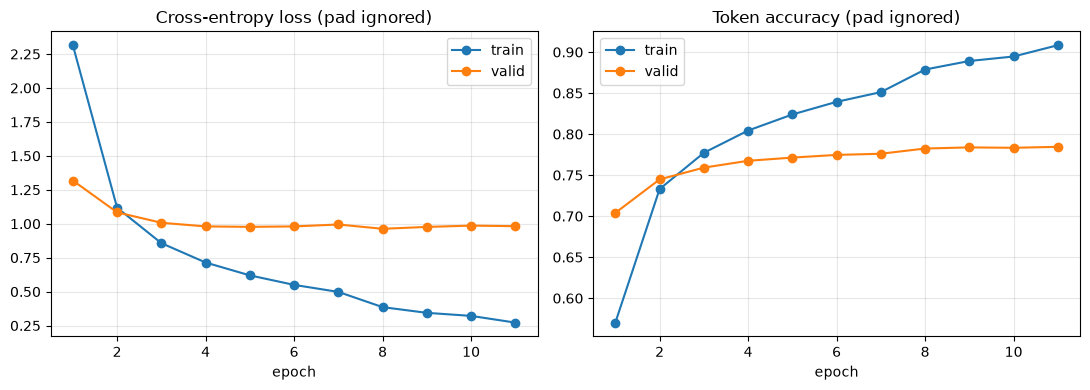

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
epochs_x = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_x, history["train_loss"], marker="o", label="train")
axes[0].plot(epochs_x, history["val_loss"], marker="o", label="valid")
axes[0].set_title("Cross-entropy loss (pad ignored)")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, history["train_acc"], marker="o", label="train")
axes[1].plot(epochs_x, history["val_acc"], marker="o", label="valid")
axes[1].set_title("Token accuracy (pad ignored)")
axes[1].set_xlabel("epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Evaluation on the test set

Same metric as validation: loss and token accuracy, padding ignored.


In [32]:
test_loss, test_acc = run_epoch(test_loader, train=False)
print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.3f}   ← non-pad French tokens only")


Test loss:     0.9686
Test accuracy: 0.782   ← non-pad French tokens only


## 10.1 Inference: translating a new sentence

Training used teacher forcing (feeding it the correct previous French word). Inference can't do that, we don't have the French sentence yet.

Greedy decoding works like this:

1. Encode the English sentence once
2. Feed `<start>` to the decoder
3. Pick the most likely next word (argmax)
4. Feed that word back in
5. Repeat until `<end>` or we hit `max_len`

It's slower than training since it's one token per step, but that's how the model actually gets used in practice.

We also return the attention matrix so we can draw a heatmap: rows are the generated French words, columns are the English words.


In [33]:
@torch.no_grad()
def translate_sentence(sentence: str, max_len: int = None, return_attention: bool = False):
    """Greedy decode one English sentence → French string."""
    model.eval()
    max_len = max_len or CONFIG["max_seq_len"]

    cleaned = clean_english(sentence)
    src_ids, src_len = src_vocab.encode(cleaned, CONFIG["max_seq_len"], add_special=False)
    src = torch.tensor(src_ids, dtype=torch.long, device=device).unsqueeze(0)  # (1, S)

    encoder_outputs, hidden, cell = model.encoder(src)
    src_mask = model.create_src_mask(src)

    token = torch.tensor([[tgt_vocab.sos_idx]], device=device)  # (1, 1)
    output_ids = []
    attn_steps = []

    for _ in range(max_len):
        logits, hidden, cell, attn = model.decoder(
            token, hidden, cell, encoder_outputs, src_mask
        )
        next_id = int(logits[0, -1].argmax())
        attn_steps.append(attn[0, 0, :src_len].detach().cpu())
        if next_id == tgt_vocab.eos_idx:
            break
        output_ids.append(next_id)
        token = torch.tensor([[next_id]], device=device)

    text = tgt_vocab.decode(output_ids)
    if return_attention:
        attn_mat = torch.stack(attn_steps, dim=0) if attn_steps else torch.zeros(1, src_len)
        src_tokens = cleaned.split()[:src_len]
        tgt_tokens = text.split()
        return text, src_tokens, tgt_tokens, attn_mat
    return text


def plot_attention(src_tokens, tgt_tokens, attn_mat, title="Attention"):
    if len(src_tokens) == 0 or len(tgt_tokens) == 0:
        print("Nothing to plot (empty translation).")
        return
    # attn_mat may have one extra row if we stopped on <end>
    rows = min(len(tgt_tokens), attn_mat.size(0))
    mat = attn_mat[:rows, :len(src_tokens)].numpy()

    fig, ax = plt.subplots(figsize=(max(4, 0.55 * len(src_tokens) + 2), max(3, 0.45 * rows + 1.5)))
    im = ax.imshow(mat, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(len(src_tokens)))
    ax.set_xticklabels(src_tokens, rotation=45, ha="right")
    ax.set_yticks(range(rows))
    ax.set_yticklabels(tgt_tokens[:rows])
    ax.set_xlabel("English (source)")
    ax.set_ylabel("French (generated)")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


print(translate_sentence("I am very happy today"))
print(translate_sentence("Where is the parking?"))


je suis très heureux aujourd hui
où se trouve le marché


## 11. BLEU and ROUGE evaluation

Token accuracy above only checks if the exact next token matched during teacher forcing, it doesn't really tell you how good the translations are when the model is running freely. So here we generate actual translations with greedy decoding and score them against the reference French sentences using two standard MT metrics:

- BLEU (Bilingual Evaluation Understudy): precision based, checks how many n-grams (1 to 4 words) in the generated sentence also show up in the reference, with a penalty if the output is too short. Higher is better, usually 0 to 1 or reported as 0 to 100.
- ROUGE (Recall-Oriented Understudy for Gisting Evaluation): originally made for summarization, but works here as a recall focused complement to BLEU. We report ROUGE-1, ROUGE-2 (n-gram overlap) and ROUGE-L (longest common subsequence), all as F-measures.

Both get computed on real greedy-decoded output, not teacher forced, since that's the realistic inference setting.


In [34]:
# Install evaluation libraries if needed (lightweight, no data download)
import sys, subprocess
try:
    from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "nltk"], check=True)
    from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

try:
    from rouge_score import rouge_scorer
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "rouge-score"], check=True)
    from rouge_score import rouge_scorer

smoothie = SmoothingFunction().method4
r_scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=False)


def evaluate_bleu_rouge(frame, n=None, seed=0):
    """Greedy-decode every (sampled) row and compute average BLEU / ROUGE vs. the reference."""
    if n is not None and n < len(frame):
        frame = frame.sample(n=n, random_state=seed).reset_index(drop=True)

    bleu_scores, rouge1, rouge2, rougeL = [], [], [], []

    for _, row in frame.iterrows():
        ref = row["French"]
        pred = translate_sentence(row["English"])

        ref_tokens = ref.split()
        pred_tokens = pred.split()
        bleu = 0.0 if not pred_tokens else sentence_bleu(
            [ref_tokens], pred_tokens, smoothing_function=smoothie
        )
        bleu_scores.append(bleu)

        scores = r_scorer.score(ref, pred)
        rouge1.append(scores["rouge1"].fmeasure)
        rouge2.append(scores["rouge2"].fmeasure)
        rougeL.append(scores["rougeL"].fmeasure)

    return {
        "BLEU": float(np.mean(bleu_scores)),
        "ROUGE-1": float(np.mean(rouge1)),
        "ROUGE-2": float(np.mean(rouge2)),
        "ROUGE-L": float(np.mean(rougeL)),
    }


print("Evaluating BLEU / ROUGE on the test set (greedy decoding, may take a few minutes)...")
# Use n=1000 (or smaller) for a quick sanity check before running on the full test set.
mt_metrics = evaluate_bleu_rouge(test_df)
print()
for name, value in mt_metrics.items():
    print(f"  {name:8s}: {value:.4f}")


Evaluating BLEU / ROUGE on the test set (greedy decoding, may take a few minutes)...

  BLEU    : 0.4147
  ROUGE-1 : 0.6960
  ROUGE-2 : 0.5231
  ROUGE-L : 0.6877


## 12. Qualitative results

Random test sentences, reference vs model output. Short and frequent phrases usually come out better than long or rare ones, which makes sense for a from-scratch LSTM with a limited vocabulary.


In [35]:
def show_translations(n=10, seed=0):
    rng = random.Random(seed)
    indices = rng.sample(range(len(test_df)), k=min(n, len(test_df)))
    rows = []
    for i in indices:
        eng = test_df.loc[i, "English"]
        ref = test_df.loc[i, "French"]
        pred = translate_sentence(eng)
        rows.append({"English": eng, "Reference (FR)": ref, "Predicted (FR)": pred})
    return pd.DataFrame(rows)


translations_df = show_translations(n=12, seed=7)
pd.set_option("display.max_colwidth", 80)
translations_df


,English,Reference (FR),Predicted (FR)
0,you must pay in advance,tu dois payer d avance,vous devez régler d avance
1,he denies himself nothing,il ne se prive de rien,il ne rien
2,i am the boss now,je suis le patron maintenant,je suis le patron maintenant
3,i know tom is a good pilot,je sais que tom est un bon pilote,je sais que tom est un bon pilote
4,we have had few typhoons this autumn,nous avons eu quelques typhons cet automne,nous avons eu quelques cet automne
5,i have to leave school,il me faut quitter l école,je dois quitter l école
6,i figured everyone was hungry,je ai pensé que tout le monde avait faim,je ai pensé que tout le monde avait faim
7,i think you are the most beautiful woman in the whole wide world,je pense que tu es la plus belle femme au monde,je pense que tu es la femme la plus belle au monde
8,maybe you were followed,peut être que tu as été suivi,peut être avez vous été suivis
9,the dogs barked all night,les chiens ont aboyé toute la nuit,les chiens toute la nuit


### Attention heatmap

Bright cells mean "when I generated this French word, I was looking at that English word." A well-trained model usually shows a roughly diagonal pattern, with some extra weight on words like *not* / *ne* that flip the meaning.


EN : can you tell me how
FR : pouvez vous me dire comment


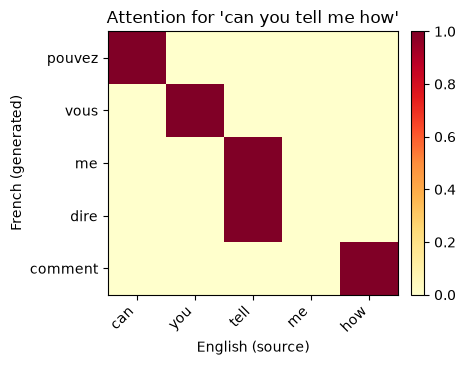

In [36]:
demo_sentence = test_df.sample(1, random_state=1).iloc[0]["English"]
pred, src_toks, tgt_toks, attn = translate_sentence(demo_sentence, return_attention=True)
print(f"EN : {demo_sentence}")
print(f"FR : {pred}")
plot_attention(src_toks, tgt_toks, attn, title=f"Attention for '{demo_sentence}'")


## 13. Try your own sentences

Type any short English sentence. Keep it close to everyday spoken English since that's what this dataset looks like.


In [37]:
your_sentences = [
    "Hi.",
    "Run!",
    "I love you.",
    "Where is the bathroom?",
    "I am not ready yet.",
    "Can you help me please?",
]

for s in your_sentences:
    print(f"{s:28s} →  {translate_sentence(s)}")


Hi.                          →  salut
Run!                         →  courez
I love you.                  →  je t aime
Where is the bathroom?       →  où sont les toilettes
I am not ready yet.          →  je ne suis pas encore prêt
Can you help me please?      →  pouvez vous m aider s il vous plaît


## 14. Save the model

You can reload `seq2seq_en_fr.pt` later without retraining. The checkpoint also stores the vocabularies, since IDs are meaningless without them.


In [38]:
ckpt_path = Path("seq2seq_en_fr.pt")
torch.save(
    {
        "model_state": model.state_dict(),
        "config": CONFIG,
        "src_word2idx": src_vocab.word2idx,
        "tgt_word2idx": tgt_vocab.word2idx,
    },
    ckpt_path,
)
print(f"Saved checkpoint → {ckpt_path.resolve()}")


Saved checkpoint → C:\Users\moham\Desktop\MIA_AI_Training\Task_6\Task_6.1\seq2seq_en_fr.pt


## 15. Workshop recap

| Piece | What it did |
|---|---|
| Cleaning | Normalized text so `Don't` and `do not` look the same |
| Vocabulary | Mapped words to IDs, with `<pad> / <unk> / <start> / <end>` |
| Encoder (BiLSTM) | Read English forwards and backwards |
| Attention | Let each French word look at the relevant English words |
| Decoder (LSTM) | Wrote French one token at a time |
| Teacher forcing | Fed the true previous word during training |
| Greedy decode | Fed the model's own previous word at test time |
| `ignore_index` | Stopped padding from inflating accuracy |
